In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Exploratory Data Analysis

## Load the dataset

In [36]:
df_cholesterol = pd.read_csv('./datasets/dataset_cholesterol.csv')
df_cholesterol.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               1000 non-null   int64  
 1    Blood Type      996 non-null    str    
 2    Smoker          997 non-null    str    
 3    Activity Level  996 non-null    str    
 4    Age             997 non-null    float64
 5    Weight          997 non-null    float64
 6    Height          997 non-null    float64
 7    Cholesterol     1000 non-null   float64
dtypes: float64(4), int64(1), str(3)
memory usage: 62.6 KB


In [37]:
# Remove the id column
df_cholesterol.drop(columns=['ID'], inplace=True)

In [38]:
# Renaming the columns
df_cholesterol.columns = [
    'bloody_type',
    'smoker', 
    'activity_level',
    'age', 
    'weight', 
    'height', 
    'cholesterol_level'
]
df_cholesterol.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bloody_type        996 non-null    str    
 1   smoker             997 non-null    str    
 2   activity_level     996 non-null    str    
 3   age                997 non-null    float64
 4   weight             997 non-null    float64
 5   height             997 non-null    float64
 6   cholesterol_level  1000 non-null   float64
dtypes: float64(4), str(3)
memory usage: 54.8 KB


In [39]:
# Copying the DF for DF_EDA and DF_Bucketing
df_cholesterol_eda = df_cholesterol.copy()
df_cholesterol_bucketing = df_cholesterol.copy()

## Processing the data and outliers

In [40]:
df_cholesterol_eda.head(10)

,bloody_type,smoker,activity_level,age,weight,height,cholesterol_level
0,B,Yes,Low,33.0,85.1,186.0,199.63
1,A,No,Moderate,68.0,105.0,184.0,236.98
2,O,No,High,25.0,64.8,180.0,161.79
3,A,No,High,43.0,120.2,167.0,336.24
4,AB,No,Low,79.0,88.5,175.0,226.23
5,B,No,Low,68.0,66.8,170.0,185.31
6,A,Yes,Low,60.0,117.3,181.0,289.33
7,O,Yes,Moderate,35.0,86.9,174.0,216.48
8,O,No,Low,62.0,81.3,166.0,235.30
9,B,Yes,High,44.0,32.7,165.0,97.79


In [41]:
# Checking for nan values
df_cholesterol_eda.isna().sum()

bloody_type          4
smoker               3
activity_level       4
age                  3
weight               3
height               3
cholesterol_level    0
dtype: int64

In [42]:
# Stats measures
df_cholesterol_eda.describe()

,age,weight,height,cholesterol_level
count,997.000000,997.000000,997.000000,1000.000000
mean,49.206620,76.496690,174.889669,199.453260
std,17.476704,21.439132,8.844703,50.625152
min,20.000000,15.400000,160.000000,36.260000
25%,34.000000,61.700000,167.000000,166.345000
50%,49.000000,75.500000,175.000000,199.455000
75%,65.000000,90.200000,183.000000,233.785000
max,79.000000,158.100000,190.000000,372.670000


In [43]:
# Collect the stats for categoric variables
mode_bloody_type = df_cholesterol_eda.bloody_type.mode()
mode_smoker = df_cholesterol_eda.smoker.mode()
mode_activity_level = df_cholesterol_eda.activity_level.mode()

In [44]:
# Collect the stats for numeric variables
median_age = df_cholesterol_eda.age.median()
median_weight = df_cholesterol_eda.weight.median()
median_height = df_cholesterol_eda.height.median()

In [45]:
# Swapping nan values
df_cholesterol_eda.fillna({
    'bloody_type': mode_bloody_type[0],
    'smoker': mode_smoker[0],
    'activity_level': mode_activity_level[0],
    'age': median_age,
    'height': median_height,
    'weight': median_weight
}, inplace=True)

,bloody_type,smoker,activity_level,age,weight,height,cholesterol_level
0,B,Yes,Low,33.0,85.1,186.0,199.63
1,A,No,Moderate,68.0,105.0,184.0,236.98
2,O,No,High,25.0,64.8,180.0,161.79
3,A,No,High,43.0,120.2,167.0,336.24
4,AB,No,Low,79.0,88.5,175.0,226.23
...,...,...,...,...,...,...,...
995,AB,Yes,Moderate,31.0,68.1,166.0,206.81
996,O,No,High,51.0,47.7,170.0,128.03
997,AB,No,Low,39.0,85.5,176.0,211.14
998,AB,Yes,Low,61.0,91.2,161.0,284.53


In [46]:
# Convert age and height to int
df_cholesterol_eda.age = df_cholesterol_eda.age.astype(int)
df_cholesterol_eda.height = df_cholesterol_eda.height.astype(int)

df_cholesterol_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bloody_type        1000 non-null   str    
 1   smoker             1000 non-null   str    
 2   activity_level     1000 non-null   str    
 3   age                1000 non-null   int64  
 4   weight             1000 non-null   float64
 5   height             1000 non-null   int64  
 6   cholesterol_level  1000 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 54.8 KB


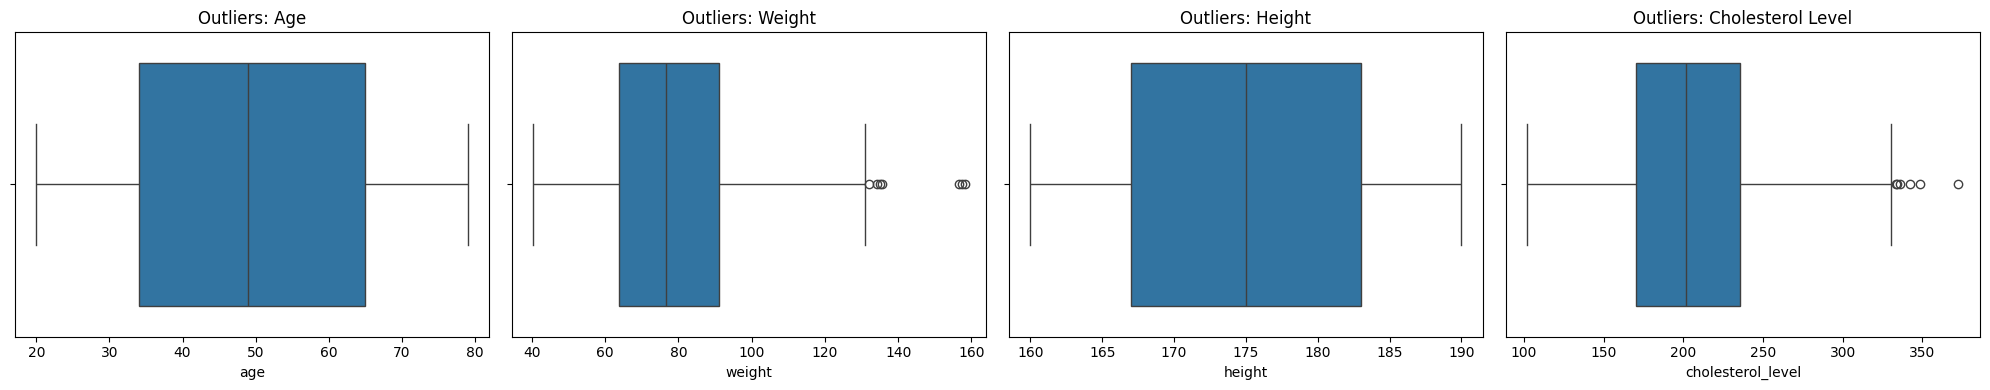

In [50]:
# Checking for outliers
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# First plot on the left (index 0)
sns.boxplot(data=df_cholesterol_eda, x='age', ax=axes[0])
axes[0].set_title("Outliers: Age")

# Second plot (index 1)
sns.boxplot(data=df_cholesterol_eda, x='weight', ax=axes[1])
axes[1].set_title("Outliers: Weight")

# Third plot (index 2)
sns.boxplot(data=df_cholesterol_eda, x='height', ax=axes[2])
axes[2].set_title("Outliers: Height")

# Fourth plot on the right (index 4)
sns.boxplot(data=df_cholesterol_eda, x='cholesterol_level', ax=axes[3])
axes[3].set_title("Outliers: Cholesterol Level")

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()

In [48]:
# Filtering targets weighing less than 40 kg
df_cholesterol_eda[df_cholesterol_eda['weight'] < 40].weight.count()

np.int64(37)

In [49]:
df_cholesterol_eda.drop(df_cholesterol_eda[df_cholesterol_eda['weight'] < 40].index, axis=0, inplace=True)

## Visualizing the data

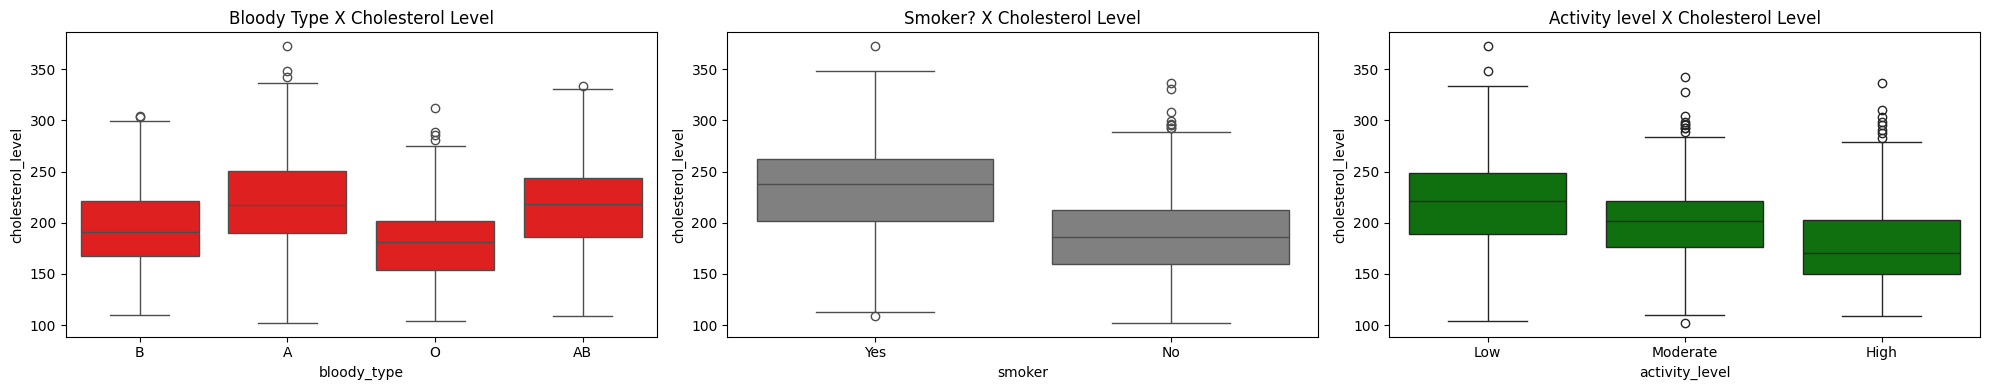

In [60]:
# Crossing categoric variables with cholesterol level
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# First plot on the left (index 0)
sns.boxplot(df_cholesterol_eda, x='bloody_type', y='cholesterol_level', ax=axes[0], color='red')
axes[0].set_title("Bloody Type X Cholesterol Level")

# Second plot (index 1)
sns.boxplot(df_cholesterol_eda, x='smoker', y='cholesterol_level', ax=axes[1], color='gray')
axes[1].set_title("Smoker? X Cholesterol Level")

# Third plot (index 2)
sns.boxplot(df_cholesterol_eda, x='activity_level', y='cholesterol_level', ax=axes[2], color='green')
axes[2].set_title("Activity level X Cholesterol Level")

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()

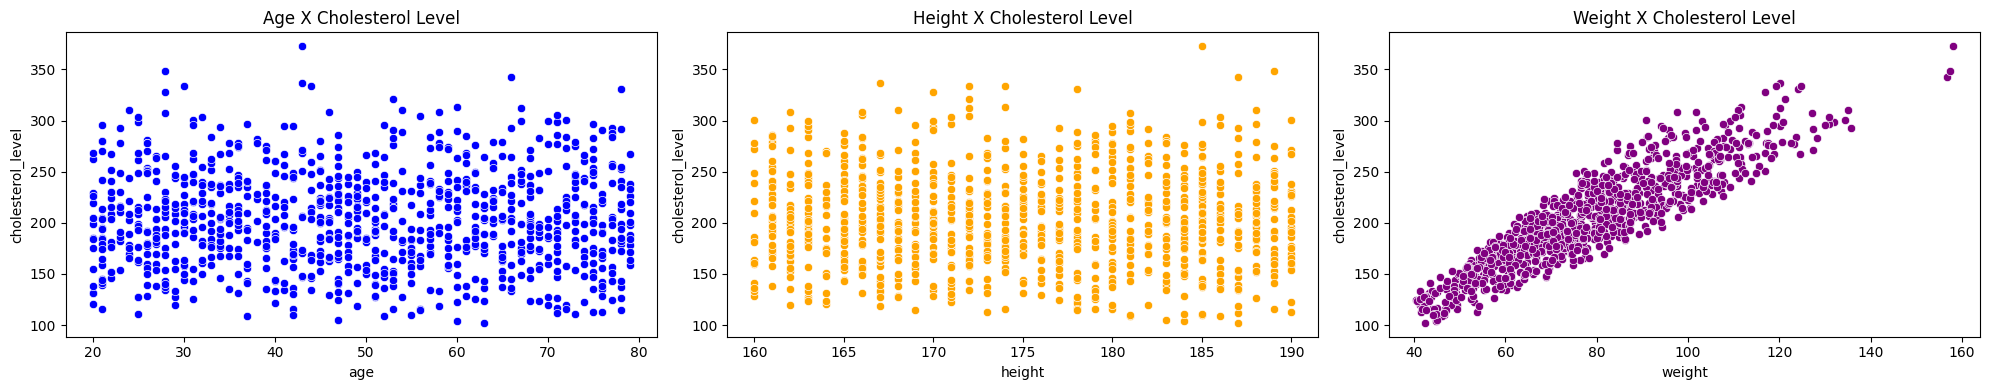

In [62]:
# Crossing numeric variables with cholesterol level
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# First plot on the left (index 0)
sns.scatterplot(df_cholesterol_eda, x='age', y='cholesterol_level', ax=axes[0], color='blue')
axes[0].set_title("Age X Cholesterol Level")

# Second plot (index 1)
sns.scatterplot(df_cholesterol_eda, x='height', y='cholesterol_level', ax=axes[1], color='orange')
axes[1].set_title("Height X Cholesterol Level")

# Third plot (index 2)
sns.scatterplot(df_cholesterol_eda, x='weight', y='cholesterol_level', ax=axes[2], color='purple')
axes[2].set_title("Weight X Cholesterol Level")

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()

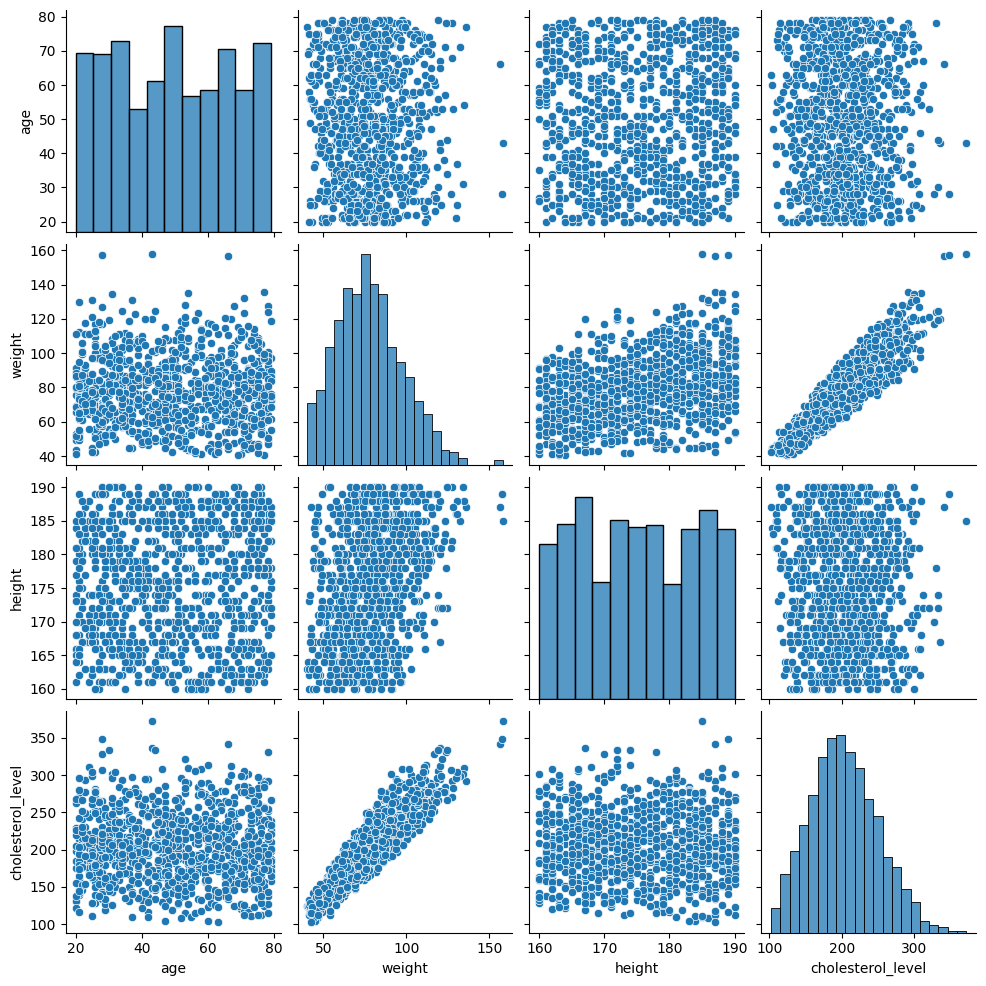

In [63]:
sns.pairplot(df_cholesterol_eda)

In [ ]:
# Convert nominal categoric variables in numerics, using One-Hot Enconder do Pandas
df_cholesterol_eda = pd.get_dummies(df_cholesterol_eda, columns=['bloody_type', 'smoker'], dtype='int64')
df_cholesterol_eda.head(10)

,activity_level,age,weight,height,cholesterol_level,bloody_type_A,bloody_type_AB,bloody_type_B,bloody_type_O,smoker_No,smoker_Yes
0,Low,33,85.1,186,199.63,0,0,1,0,0,1
1,Moderate,68,105.0,184,236.98,1,0,0,0,1,0
2,High,25,64.8,180,161.79,0,0,0,1,1,0
3,High,43,120.2,167,336.24,1,0,0,0,1,0
4,Low,79,88.5,175,226.23,0,1,0,0,1,0
5,Low,68,66.8,170,185.31,0,0,1,0,1,0
6,Low,60,117.3,181,289.33,1,0,0,0,0,1
7,Moderate,35,86.9,174,216.48,0,0,0,1,0,1
8,Low,62,81.3,166,235.30,0,0,0,1,1,0
10,Low,57,123.6,183,283.87,1,0,0,0,0,1


In [66]:
# Convert ordinal categoric variables in numerics, using One-Hot Enconder do Pandas
df_cholesterol_eda.activity_level = pd.factorize(df_cholesterol_eda.activity_level)[0] + 1
df_cholesterol_eda.head(10)

,activity_level,age,weight,height,cholesterol_level,bloody_type_A,bloody_type_AB,bloody_type_B,bloody_type_O,smoker_No,smoker_Yes
0,1,33,85.1,186,199.63,0,0,1,0,0,1
1,2,68,105.0,184,236.98,1,0,0,0,1,0
2,3,25,64.8,180,161.79,0,0,0,1,1,0
3,3,43,120.2,167,336.24,1,0,0,0,1,0
4,1,79,88.5,175,226.23,0,1,0,0,1,0
5,1,68,66.8,170,185.31,0,0,1,0,1,0
6,1,60,117.3,181,289.33,1,0,0,0,0,1
7,2,35,86.9,174,216.48,0,0,0,1,0,1
8,1,62,81.3,166,235.30,0,0,0,1,1,0
10,1,57,123.6,183,283.87,1,0,0,0,0,1


<Axes: >

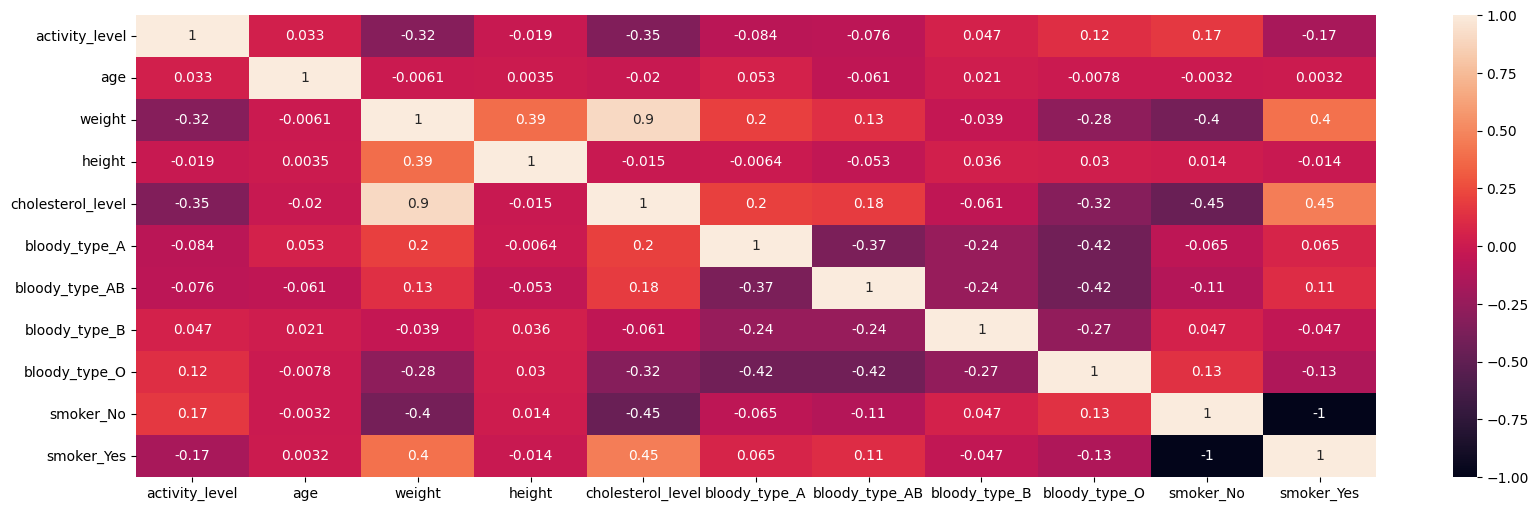

In [68]:
# Heatmap
plt.figure(figsize=(20,6))
sns.heatmap(df_cholesterol_eda.corr(), vmax=1, vmin=-1, annot=True)

<Axes: >

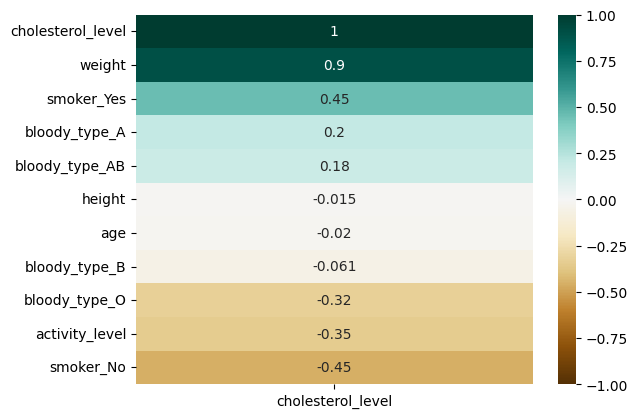

In [71]:
# Ranking format with only the target variable
sns.heatmap(
                df_cholesterol_eda.corr()[['cholesterol_level']].sort_values(
                                                                                by='cholesterol_level', 
                                                                                ascending=False
                                                                            ), 
                vmax=1, 
                vmin=-1, 
                cmap='BrBG',
                annot=True
            )

### Bucketing

In [75]:
# Age
bins_age = [20, 30, 40, 50, 60, 70, 80]
labels_age = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79',]
df_cholesterol_bucketing['age_scale'] = pd.cut(x=df_cholesterol_bucketing.age, bins=bins_age, labels=labels_age, include_lowest=True)

df_cholesterol_bucketing.head(10)

,bloody_type,smoker,activity_level,age,weight,height,cholesterol_level,age_scale
0,B,Yes,Low,33.0,85.1,186.0,199.63,30-39
1,A,No,Moderate,68.0,105.0,184.0,236.98,60-69
2,O,No,High,25.0,64.8,180.0,161.79,20-29
3,A,No,High,43.0,120.2,167.0,336.24,40-49
4,AB,No,Low,79.0,88.5,175.0,226.23,70-79
5,B,No,Low,68.0,66.8,170.0,185.31,60-69
6,A,Yes,Low,60.0,117.3,181.0,289.33,50-59
7,O,Yes,Moderate,35.0,86.9,174.0,216.48,30-39
8,O,No,Low,62.0,81.3,166.0,235.30,60-69
9,B,Yes,High,44.0,32.7,165.0,97.79,40-49


<Axes: xlabel='age_scale', ylabel='cholesterol_level'>

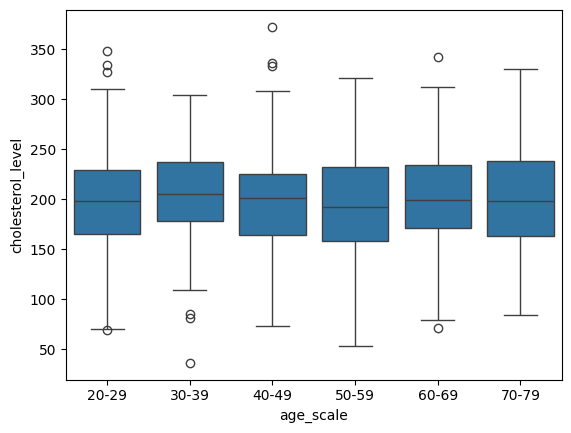

In [76]:
sns.boxplot(df_cholesterol_bucketing, x='age_scale', y='cholesterol_level')